In [4]:
import pandas as pd 
import numpy as np 
import csv
df=pd.read_csv("Housing1.csv")
df 



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
df.shape

(20640, 10)

## handle missing values

In [8]:
df = df.dropna()

print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [13]:
#to use splitting train and test data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [9]:
#one hot coded column  
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [11]:
#feature and target 
import matplotlib.pyplot as plt
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [14]:
#train test spilt data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
#training the model 
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
#prediction 
y_pred = model.predict(X_test)

In [18]:
#metrices 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 4802173538.6041565
RMSE: 69297.71669113028
MAE : 50413.43330810058
R²  : 0.6488402154431996


In [19]:
#actual vs predicted 10 rows 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,245800.0,201882.959868
1,137900.0,147279.682144
2,218200.0,207796.609798
3,220800.0,180487.576722
4,170500.0,190323.923130
5,75000.0,95437.897104
6,269400.0,287156.451612
7,228900.0,257624.771805
8,500001.0,385383.556151
9,80800.0,62548.197551


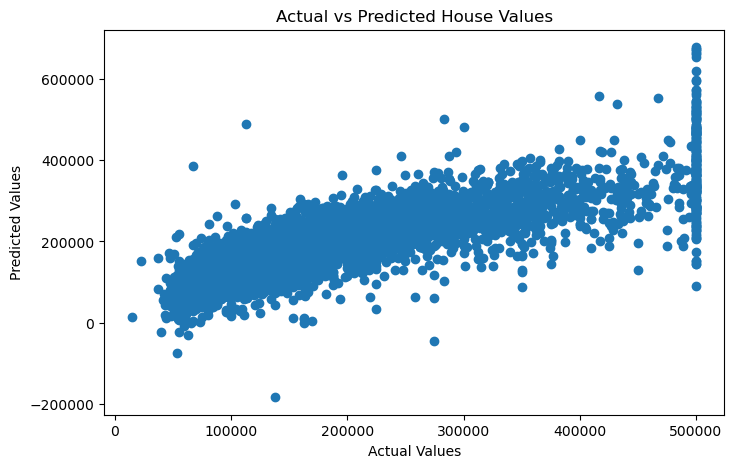

In [20]:
#actual vs predicted ploting graph 
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")
plt.show() 


## task -2 


In [21]:
#using one feature 
X_A = df[["median_income"]]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y,
    test_size=0.2,
    random_state=42
)

model_A = LinearRegression()
model_A.fit(X_train_A, y_train_A)

pred_A = model_A.predict(X_test_A)

In [22]:
#using multiple features 
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

X_B = df[features]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y,
    test_size=0.2,
    random_state=42
)

model_B = LinearRegression()
model_B.fit(X_train_B, y_train_B)

pred_B = model_B.predict(X_test_B)

In [23]:
#comparison 
results = pd.DataFrame({
    "Model": ["One Feature", "Multi Feature"],
    "MSE": [
        mean_squared_error(y_test_A, pred_A),
        mean_squared_error(y_test_B, pred_B)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_A, pred_A)),
        np.sqrt(mean_squared_error(y_test_B, pred_B))
    ],
    "MAE": [
        mean_absolute_error(y_test_A, pred_A),
        mean_absolute_error(y_test_B, pred_B)
    ],
    "R2": [
        r2_score(y_test_A, pred_A),
        r2_score(y_test_B, pred_B)
    ]
})

results

,Model,MSE,RMSE,MAE,R2
0,One Feature,7.221011e+09,84976.533256,63374.551304,0.471962
1,Multi Feature,6.602599e+09,81256.381157,60866.561000,0.517184


In [24]:
#result 
print("""
The Multi-Feature model performed better because it uses
more relevant information and achieved lower error values
and a higher R² score on the test set.
""")


The Multi-Feature model performed better because it uses
more relevant information and achieved lower error values
and a higher R² score on the test set.



## task-3 Different Train/Test Splits

In [25]:
splits = [0.2, 0.3, 0.4]

records = []

for split in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X_B,
        y,
        test_size=split,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    records.append({
        "Split": f"{int((1-split)*100)}/{int(split*100)}",

        "Train_MSE": mean_squared_error(y_train, train_pred),
        "Test_MSE": mean_squared_error(y_test, test_pred),

        "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),

        "Train_MAE": mean_absolute_error(y_train, train_pred),
        "Test_MAE": mean_absolute_error(y_test, test_pred),

        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred)
    })

split_results = pd.DataFrame(records)
split_results

,Split,Train_MSE,Test_MSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,80/20,6.390501e+09,6.602599e+09,79940.607293,81256.381157,59827.991516,60866.561000,0.517220,0.517184
1,70/30,6.435930e+09,6.426520e+09,80224.248849,80165.578669,59970.172412,60401.320131,0.516876,0.517924
2,60/40,6.537252e+09,6.277077e+09,80853.274576,79228.008631,60386.905277,59742.438208,0.513584,0.522701


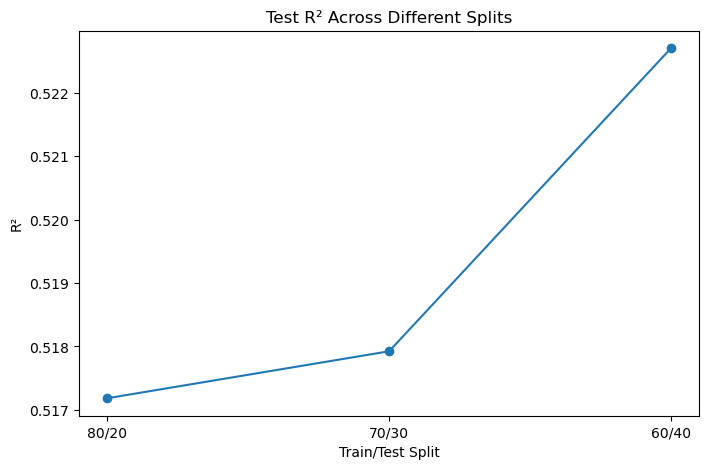

In [26]:
#visualization 
plt.figure(figsize=(8,5))

plt.plot(
    split_results["Split"],
    split_results["Test_R2"],
    marker="o"
)

plt.title("Test R² Across Different Splits")
plt.xlabel("Train/Test Split")
plt.ylabel("R²")
plt.show()

In [27]:
#result 
print("""
Compare Train and Test metrics.

A smaller train-test gap indicates a more stable model.
Choose the split with the best balance between test performance
and stability.
""") 


Compare Train and Test metrics.

A smaller train-test gap indicates a more stable model.
Choose the split with the best balance between test performance
and stability.



## matrix verifications and exploration 

In [28]:
## metrix verification 
errors = y_test_B.values - pred_B

manual_mse = np.mean(errors**2)
manual_rmse = np.sqrt(manual_mse)
manual_mae = np.mean(np.abs(errors))

ss_res = np.sum(errors**2)
ss_tot = np.sum((y_test_B - np.mean(y_test_B))**2)

manual_r2 = 1 - (ss_res / ss_tot)

print("Manual MSE :", manual_mse)
print("Manual RMSE:", manual_rmse)
print("Manual MAE :", manual_mae)
print("Manual R2  :", manual_r2)

Manual MSE : 6602599478.654308
Manual RMSE: 81256.381156524
Manual MAE : 60866.56099957579
Manual R2  : 0.5171837519405795


In [29]:
#extra metri 
from sklearn.metrics import median_absolute_error

medae = median_absolute_error(y_test_B, pred_B)

print("Median Absolute Error:", medae)

Median Absolute Error: 48434.23873280123


In [30]:
#matrix table comparison 
metrics_table = pd.DataFrame({
    "Metric": ["MSE","RMSE","MAE","R2","MedianAE"],
    "Value": [
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        medae
    ]
})

metrics_table

,Metric,Value
0,MSE,6.602599e+09
1,RMSE,8.125638e+04
2,MAE,6.086656e+04
3,R2,5.171838e-01
4,MedianAE,4.843424e+04


In [31]:
#Artificial Large Errors Experiment
modified_pred = pred_B.copy()

modified_pred[:3] += 500000

mse_large = mean_squared_error(y_test_B, modified_pred)
rmse_large = np.sqrt(mse_large)
mae_large = mean_absolute_error(y_test_B, modified_pred)

comparison = pd.DataFrame({
    "Metric": ["MSE","RMSE","MAE"],
    "Original": [
        mean_squared_error(y_test_B, pred_B),
        np.sqrt(mean_squared_error(y_test_B, pred_B)),
        mean_absolute_error(y_test_B, pred_B)
    ],
    "After Large Errors": [
        mse_large,
        rmse_large,
        mae_large
    ]
})

comparison

,Metric,Original,After Large Errors
0,MSE,6.602599e+09,6.769352e+09
1,RMSE,8.125638e+04,8.227607e+04
2,MAE,6.086656e+04,6.117333e+04


In [32]:
print("""
MSE reacts the most strongly to large prediction errors
because errors are squared.

RMSE also increases significantly because it is derived
from MSE.

MAE increases too, but less aggressively because it uses
absolute values rather than squared values.
""")


MSE reacts the most strongly to large prediction errors
because errors are squared.

RMSE also increases significantly because it is derived
from MSE.

MAE increases too, but less aggressively because it uses
absolute values rather than squared values.

